### Librairies

In [262]:
import pandas as pd
import numpy as np
from config import make_pca_config
from data_loader import load_price_panel
from backtest import run_backtest
from performance import summarize_backtest
from plots import *

### Load data

In [263]:
file_map_5 = {
    "AD1": "data_elsa\AD1_COMB_Curncy.xlsx",
    "CD1": "data_elsa\CD1_COMB_Curncy.xlsx", 
    "EC1": "data_elsa\EC1_COMB_Curncy.xlsx",
    "SF1": "data_elsa\SF1_COMB_Curncy.xlsx" 
}

file_map_6 = {
    "C1": "data_elsa\C1_COMB_Comdty.xlsx",
    "C01": "data_elsa\CO1_Comdty.xlsx", 
    "CL1": "data_elsa\CL1_COMB_Comdty.xlsx",
    "GC1": "data_elsa\GC1_COMB_Comdty.xlsx",
    "GX1": "data_elsa\GX1_Index.xlsx",
    "HG1": "data_elsa\HG1_COMB_Comdty.xlsx",
    "HI1": "data_elsa\HI1_COMB_Index.xlsx",
    "LA1": "data_elsa\LA1_Comdty.xlsx",
    "NQ1": "data_elsa\_NQ1_Index.xlsx",
    "VG1": "data_elsa\VG1_Index.xlsx",
    "W1": "data_elsa\W1_COMB_Comdty.xlsx"
}

prices_5 = load_price_panel(file_map=file_map_5, sheet_name=0, header=5, date_col="Date", price_col="PX_LAST")
prices_6 = load_price_panel(file_map=file_map_6, sheet_name=0, header=6, date_col="Date", price_col="PX_LAST")
prices = pd.concat([prices_5, prices_6], axis=1)
# prices = prices.dropna()
prices.isna().sum()

AD1     157
CD1     160
EC1     161
SF1     158
C1      198
C01      51
CL1     212
GC1     212
GX1     108
HG1     212
HI1     266
LA1    6539
NQ1     156
VG1     108
W1      198
dtype: int64

In [264]:
prices = prices.drop(columns=["LA1", "CL1"])
prices = prices.interpolate(method='linear', limit_direction='both')
prices.isna().sum()

AD1    0
CD1    0
EC1    0
SF1    0
C1     0
C01    0
GC1    0
GX1    0
HG1    0
HI1    0
NQ1    0
VG1    0
W1     0
dtype: int64

### Backtest strat PCA fixed and variable

In [265]:
import importlib
import config
import plots
import performance
import backtest
import portfolio

importlib.reload(portfolio)
importlib.reload(performance)
importlib.reload(backtest)
importlib.reload(config)
importlib.reload(plots)

<module 'plots' from 'c:\\Users\\33761\\OneDrive - CentraleSupelec\\Documents\\Cours 4A\\Cross Asset Investment\\code\\plots.py'>

In [234]:
from performance import summarize_backtest
print(summarize_backtest.__annotations__.keys())

dict_keys(['equity_curve', 'daily_returns', 'turnover', 'nb_trades', 'return'])


In [266]:
cfg_fixed = make_pca_config()
cfg_fixed.pca_mode = "fixed"
cfg_fixed.n_factors_fixed = 5
cfg_fixed.sbo = 2.0
cfg_fixed.sso = 2.0
cfg_fixed.sbc = 0.5
cfg_fixed.ssc = 0.5
cfg_fixed.validate()

res_fixed = run_backtest(prices, cfg_fixed)

summary_fixed = summarize_backtest(
    equity_curve=res_fixed.equity_curve,
    daily_returns=res_fixed.daily_returns,
    turnover=res_fixed.turnover,
    nb_trades= res_fixed.total_trade_count
)
summary_fixed

total_return            2.134536
annualized_return       0.045013
annualized_vol          0.191806
sharpe                  0.324638
max_drawdown           -0.533737
hit_ratio               0.386756
nb_trades            1958.000000
avg_turnover            0.252353
median_turnover         0.000000
Name: performance, dtype: float64

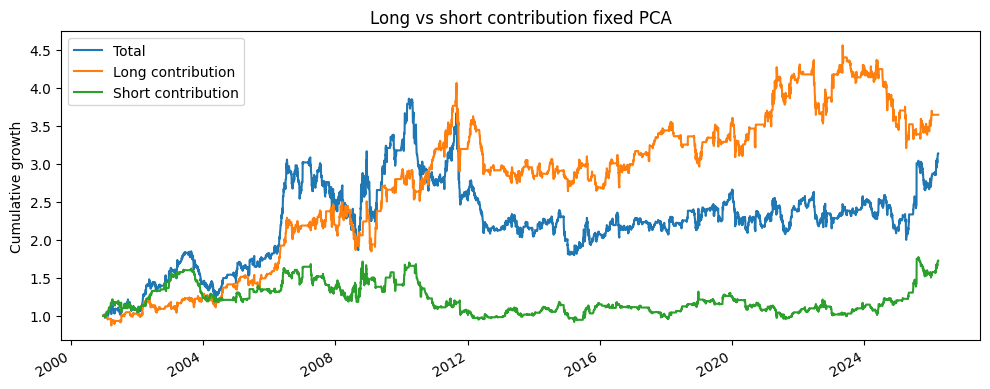

In [ ]:
plot_long_short_contribution(
    total_returns=res_fixed.daily_returns,
    long_contribution=res_fixed.long_contribution,
    short_contribution=res_sfixed.short_contribution,
    title="Long vs short contribution fixed PCA"
)

In [268]:
cfg_var = make_pca_config()
cfg_var.pca_mode = "variance"
cfg_var.explained_variance_target = 0.55
cfg_var.sbo = 2.0
cfg_var.sso = 2.0
cfg_var.sbc = 0.5
cfg_var.ssc = 0.5
cfg_var.validate()

res_var = run_backtest(prices, cfg_var)

summary_var = summarize_backtest(
    equity_curve=res_var.equity_curve,
    daily_returns=res_var.daily_returns,
    turnover=res_var.turnover,
    nb_trades= res_var.total_trade_count
)
summary_var

total_return            0.169471
annualized_return       0.006051
annualized_vol          0.196035
sharpe                  0.128184
max_drawdown           -0.660106
hit_ratio               0.421624
nb_trades            2145.000000
avg_turnover            0.266686
median_turnover         0.000000
Name: performance, dtype: float64

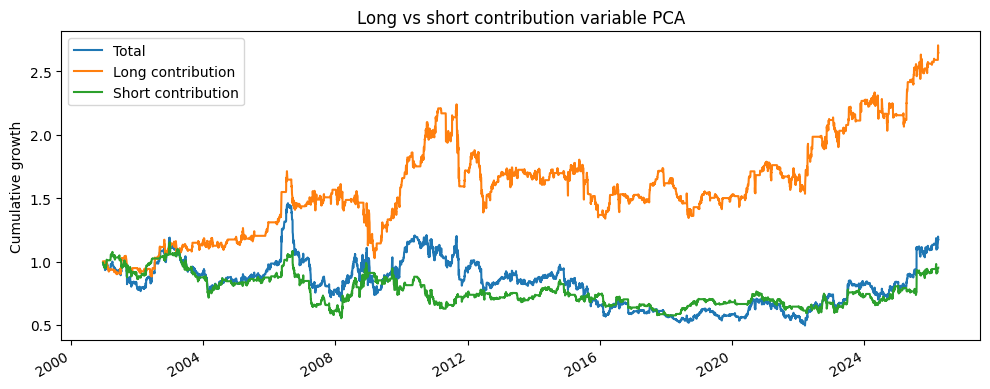

In [269]:
plot_long_short_contribution(
    total_returns=res_var.daily_returns,
    long_contribution=res_var.long_contribution,
    short_contribution=res_var.short_contribution,
    title="Long vs short contribution variable PCA"
)

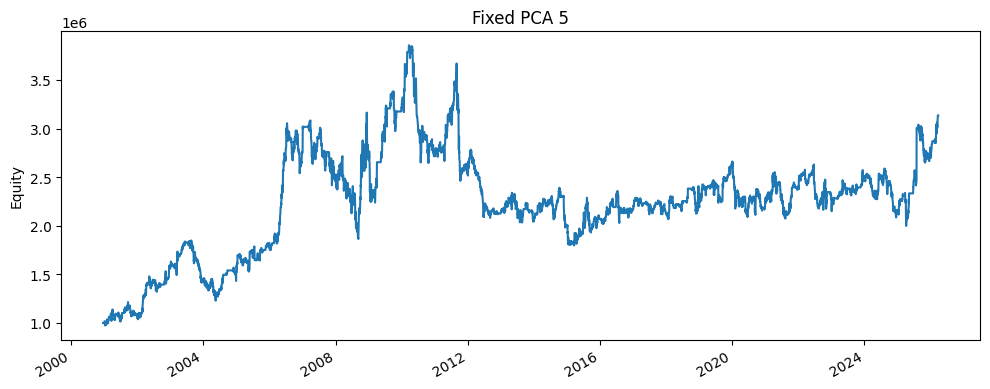

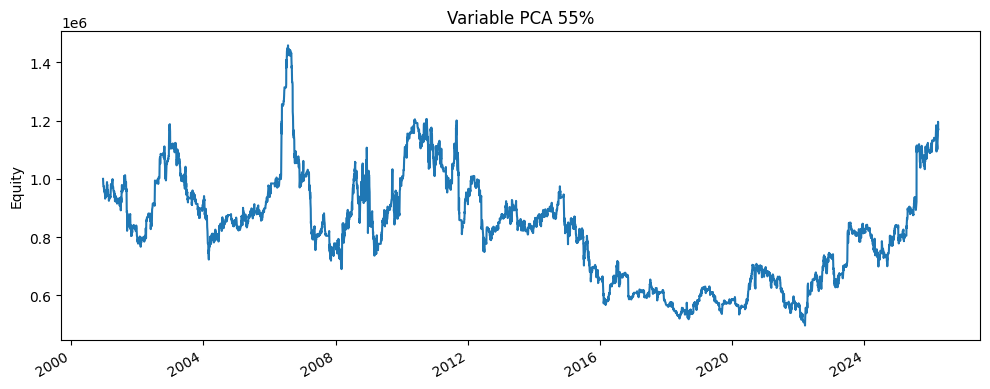

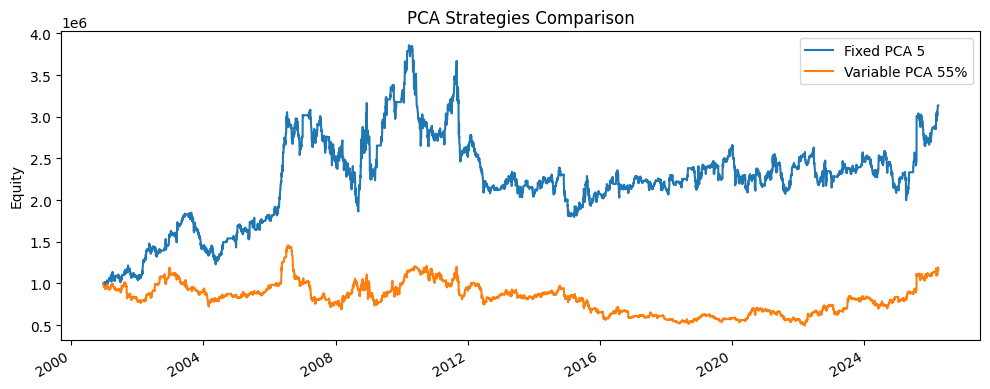

In [270]:
plot_equity_curve(res_fixed.equity_curve, title=f"Fixed PCA {cfg_fixed.n_factors_fixed}")
plot_equity_curve(res_var.equity_curve, title=f"Variable PCA {cfg_var.explained_variance_target*100:.0f}%")
plot_strategy_comparison(
    {
        f"Fixed PCA {cfg_fixed.n_factors_fixed}": res_fixed.equity_curve,
        f"Variable PCA {cfg_var.explained_variance_target*100:.0f}%": res_var.equity_curve,
    },
    title="PCA Strategies Comparison",
)

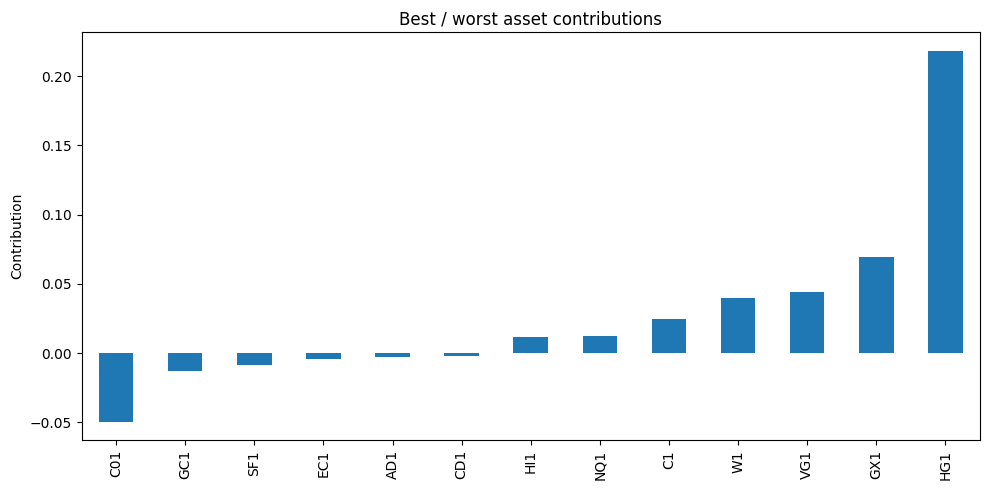

In [286]:
period_contrib = res_var.contribution_by_asset.loc["2025-01-01":"2025-12-12"].sum() # "2006-01-01":"2020-05-31"

plot_asset_contribution_bar(
    period_contrib,
    title="Best / worst asset contributions"
)

In [272]:
res_fixed.diagnostics[(res_fixed.diagnostics.n_longs > 0) | (res_fixed.diagnostics.n_shorts > 0)]

,n_assets,n_factors,selected_variance,n_longs,n_shorts,gross,turnover,trade_count
date,,,,,,,,
2001-01-03,13,5,0.677719,2,0,1.0,1.0,2
2001-01-04,13,5,0.677295,2,1,2.0,1.0,1
2001-01-05,13,5,0.676795,2,1,2.0,0.0,0
2001-01-08,13,5,0.676840,2,1,2.0,0.0,0
2001-01-09,13,5,0.677387,2,1,2.0,0.0,0
...,...,...,...,...,...,...,...,...
2026-03-16,13,5,0.777916,0,1,1.0,0.0,0
2026-03-17,13,5,0.777958,0,1,1.0,0.0,0
2026-03-18,13,5,0.778283,0,1,1.0,0.0,0


In [284]:
res_fixed.weights_history[res_fixed.weights_history.sum(axis=1)>0]

,AD1,CD1,EC1,SF1,C1,C01,GC1,GX1,HG1,HI1,NQ1,VG1,W1
2001-01-03,0.0,0.0,0.0,0.0,0.000000,0.0,0.500000,0.0,0.000000,0.000000,0.000000,0.5,0.0
2001-02-01,0.0,0.0,0.0,0.0,0.000000,0.0,0.500000,0.0,0.000000,0.000000,0.000000,0.5,0.0
2001-02-02,0.0,0.0,0.0,0.0,0.000000,0.0,0.500000,0.0,0.000000,0.000000,0.000000,0.5,0.0
2001-02-05,0.0,0.0,0.0,0.0,0.000000,0.0,0.500000,0.0,0.000000,0.000000,0.000000,0.5,0.0
2001-02-06,0.0,0.0,0.0,0.0,0.000000,0.0,0.500000,0.0,0.000000,0.000000,0.000000,0.5,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-09-19,0.0,0.0,0.0,0.0,-0.333333,0.0,-0.333333,0.5,0.000000,-0.333333,0.000000,0.0,0.5
2025-09-22,0.0,0.0,0.0,0.0,-0.333333,0.0,-0.333333,0.5,0.000000,-0.333333,0.000000,0.0,0.5
2025-10-13,0.0,0.0,0.5,0.0,-0.333333,0.0,-0.333333,0.0,0.000000,0.500000,-0.333333,0.0,0.0
2025-10-17,0.0,0.0,0.5,0.0,0.000000,0.0,-0.333333,0.0,-0.333333,0.500000,-0.333333,0.0,0.0


In [274]:
res_fixed.states_history[res_fixed.states_history.sum(axis=1)>2]

,AD1,CD1,EC1,SF1,C1,C01,GC1,GX1,HG1,HI1,NQ1,VG1,W1
2002-03-27,0,1,1,0,0,0,0,0,1,0,0,0,0
2002-03-28,0,1,1,0,1,0,0,0,1,0,0,0,0
2002-04-01,0,1,1,0,1,0,0,0,1,0,0,0,0
2002-04-02,0,1,1,0,1,0,0,0,1,0,0,0,0
2002-04-03,0,1,1,0,1,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-04-16,0,1,0,1,0,0,0,0,0,0,0,1,0
2025-06-27,1,0,0,0,1,0,0,0,0,0,0,1,0
2025-06-30,1,0,0,0,1,0,0,0,0,0,0,1,0
2025-07-01,1,0,0,0,1,0,0,0,0,0,0,1,0


### Grid Search on Fixed PCA Parameters

In [244]:
import itertools
import pickle
from pathlib import Path

# Get number of assets
n_assets = len(prices.columns)
print(f"Number of assets: {n_assets}")

# Define grid parameters
n_factors_range = range(5, n_assets + 1)
signal_levels = np.arange(1.5, 2.5, 0.5)

# Store results
grid_results = {}
summary_data = []

# Grid search over all combinations
total_combinations = len(n_factors_range) * len(signal_levels) ** 4
print(f"Total combinations to test: {total_combinations}")

combination_count = 0
for n_f in n_factors_range:
    for sbo in signal_levels:
        for sso in signal_levels:
            for sbc in signal_levels:
                for ssc in signal_levels:
                    combination_count += 1
                    
                    # Create config
                    cfg_grid = make_pca_config()
                    cfg_grid.pca_mode = "fixed"
                    cfg_grid.n_factors_fixed = n_f 
                    cfg_grid.sbo = sbo
                    cfg_grid.sso = sso
                    cfg_grid.sbc = sbc
                    cfg_grid.ssc = ssc
                    
                    try:
                        cfg_grid.validate()
                        
                        # Run backtest
                        res_grid = run_backtest(prices, cfg_grid)
                        
                        # Summarize
                        summary_fixed = summarize_backtest(
                            equity_curve=res_grid.equity_curve,
                            daily_returns=res_grid.daily_returns,
                            turnover=res_grid.turnover,
                            nb_trades=res_grid.total_trade_count
                        )
                        
                        # Store results
                        config_key = f"n_f={n_f}_sbo={sbo:.2f}_sso={sso:.2f}_sbc={sbc:.2f}_ssc={ssc:.2f}"
                        grid_results[config_key] = {
                            'config': cfg_grid,
                            'result': res_grid,
                            'summary': summary_fixed
                        }
                        
                        # Collect summary data
                        summary_dict = summary_fixed.to_dict() if hasattr(summary_fixed, 'to_dict') else dict(summary_fixed)
                        summary_dict.update({
                            'n_factors_fixed': n_f,
                            'sbo': sbo,
                            'sso': sso,
                            'sbc': sbc,
                            'ssc': ssc
                        })
                        summary_data.append(summary_dict)
                        
                        if combination_count % 50 == 0:
                            print(f"Completed {combination_count}/{total_combinations} combinations")
                            
                    except Exception as e:
                        print(f"Error with config {config_key}: {str(e)}")
                        continue

print(f"\nGrid search completed! Total successful configs: {len(grid_results)}")

# Save results to pickle
output_dir = Path("grid_search_results")
output_dir.mkdir(exist_ok=True)

with open(output_dir / "grid_search_full.pkl", "wb") as f:
    pickle.dump(grid_results, f)

# Save summaries to CSV for easier analysis
summary_df = pd.DataFrame(summary_data)
summary_df.to_csv(output_dir / "grid_search_summaries.csv", index=False)

print(f"Results saved to {output_dir}")
print(f"Summary dataframe shape: {summary_df.shape}")
print("\nSummary dataframe columns:")
print(summary_df.columns.tolist())


Number of assets: 13
Total combinations to test: 2304


KeyboardInterrupt: 

### Dive into backtestng steps

In [275]:
cfg = make_pca_config()
cfg.min_assets = 5
cfg.store_snapshots = True
cfg.snapshot_start = "2020-04-18"
cfg.snapshot_end = "2020-04-26"
# cfg.snapshot_dates = ["2006-01-31", "2006-02-15", "2006-03-31"]

In [276]:
res = run_backtest(prices, cfg)
summary = summarize_backtest(
    equity_curve=res.equity_curve,
    daily_returns=res.daily_returns,
    turnover=res.turnover,
)
summary

total_return        -0.452816
annualized_return   -0.022969
annualized_vol       0.162634
sharpe              -0.062482
max_drawdown        -0.764784
hit_ratio            0.422848
nb_trades                 NaN
avg_turnover         0.559077
median_turnover      0.000000
Name: performance, dtype: float64

In [277]:
date = sorted(res.snapshots.keys())[2]
snap = res.snapshots[date]

# snap.correlation_matrix.head()
# snap.eigenvalues[:10]
# snap.eigenvectors.iloc[:5, :5]
# snap.ou_table.head()
# snap.full_score.sort_values().dropna().head(10)

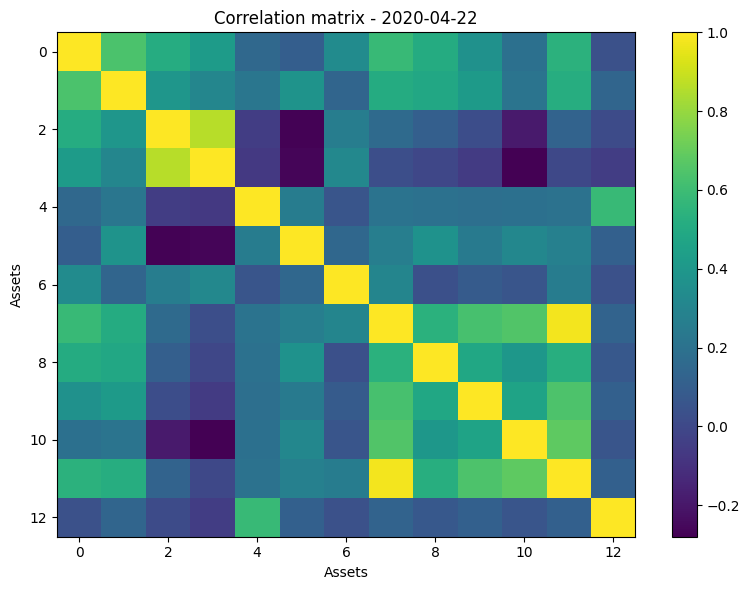

In [278]:
# Visualiser la matrice de corrélation
plot_correlation_matrix(
    snap.correlation_matrix,
    title=f"Correlation matrix - {date.date()}"
)

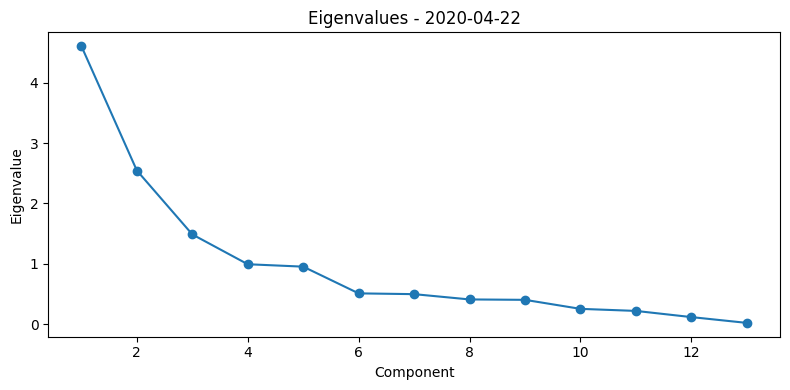

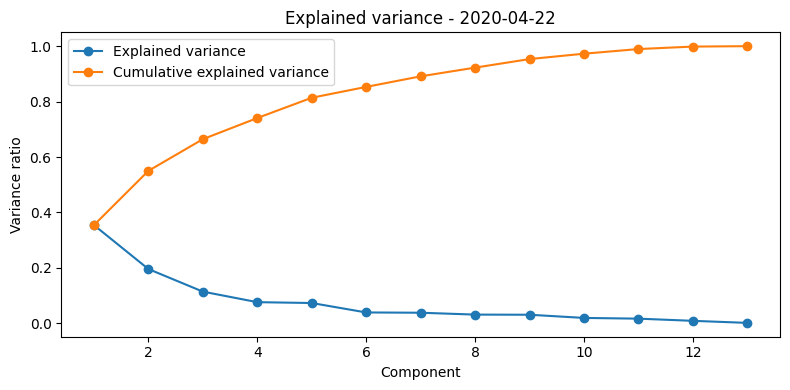

In [279]:
# Visualiser eigenvalues et variance expliquée
plot_scree(snap.eigenvalues, title=f"Eigenvalues - {date.date()}")
plot_explained_variance(snap.eigenvalues, title=f"Explained variance - {date.date()}")

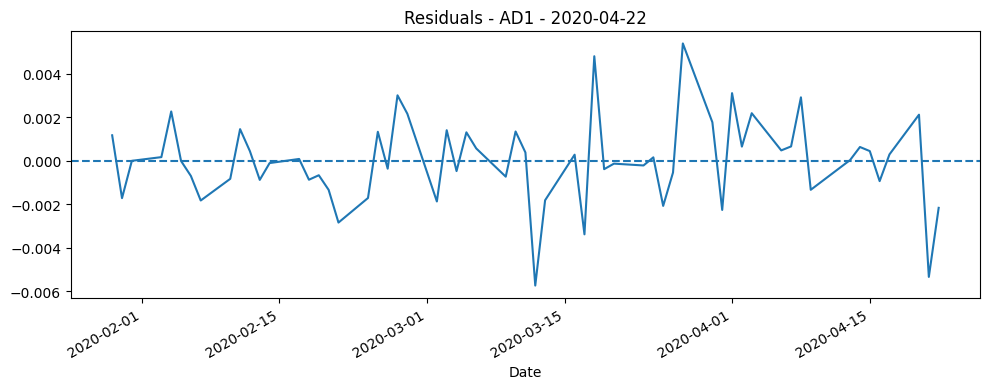

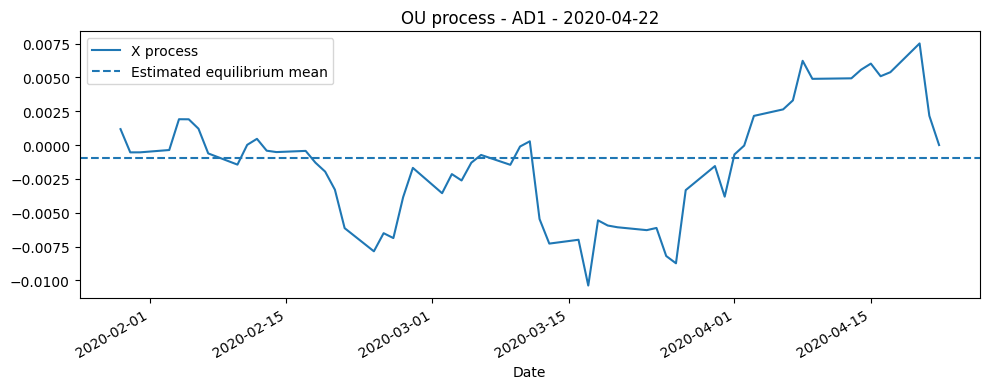

In [280]:
# Visualiser l’étape OU pour un ticker
ticker = snap.ou_table.index[0]

plot_residuals( 
    snap.residuals_window[ticker],
    title=f"Residuals - {ticker} - {date.date()}"
)

plot_ou_process(
    snap.x_process_window[ticker],
    equilibrium_mean=snap.ou_table.loc[ticker, "m"],
    title=f"OU process - {ticker} - {date.date()}"
)

### Archives

In [ ]:
dr = pd.DataFrame(res.daily_returns, columns= ["daily_rets"])
dr.set_index(dr.index, inplace=True)
dr.iloc[np.argmin(res.daily_returns)]

In [ ]:
# Visualiser un eigenvector ou un eigenportfolio
plot_factor_loadings(
    snap.eigenvectors["factor_1"],
    top_n=20,
    title=f"Eigenvector loadings - factor_1 - {date.date()}"
)

plot_factor_loadings(
    snap.factor_weights["factor_1"],
    top_n=20,
    title=f"Eigenportfolio weights - factor_1 - {date.date()}"
)

In [ ]:
# Visualiser le full score
plot_full_score(
    snap.full_score,
    title=f"Full score - {date.date()}",
    top_n=15
)

plot_score_distribution(
    snap.full_score,
    title=f"Score distribution - {date.date()}"
)